# MGMT298D: Science and Strategy of AI
## Assignment 1 - Linear Regression with Feature Engineering
### Application: Sales Forecasting at H&M

---

**Instructions:** Complete the exercises by filling in the `???` placeholders and answering the questions. Run all code cells in order.

## Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("https://raw.githubusercontent.com/ucla-anderson-SSAI/SSAI/refs/heads/main/HMData.csv")
print(f"Loaded {len(df):,} rows")

Loaded 35,856 rows


## Select a Product Category

In [5]:
# AVAILABLE CATEGORIES:
# Bag, Belt, Blazer, Blouse, Bodysuit, Boots, Cardigan, Coat, Costumes, Dress, Hat/beanie, Hat/brim, 
# Hoodie, Jacket, Jumpsuit/Playsuit, Leggings/Tights, Sandals, Shirt, Shorts, Skirt, Sneakers, Socks, Sunglasses, Sweater, 
# Swimsuit, T-shirt, Top, Trousers, Vest top

SELECTED_PRODUCT = 'T-shirt'  # <-- Fill in a product name (as a string)

df_sub = df[df["name"] == SELECTED_PRODUCT].copy()
month_cols = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# Create month_num column
df_sub["month_num"] = df_sub[month_cols].idxmax(axis=1).map({m: i+1 for i, m in enumerate(month_cols)})
months_sub = np.sort(df_sub["month_num"].unique())

## Feature Engineering

In [7]:
# Create lag and temporal features (same as lecture)
for i in range(1, 4):
    df_sub[f"lag_m{i}"] = df_sub.groupby("id")["sales"].shift(i)
df_sub["ma_3"] = df_sub.groupby("id")["sales"].shift(1).rolling(3, min_periods=1).mean().values
df_sub["price_change"] = df_sub.groupby("id")["price"].pct_change()
df_sub[["lag_m1", "lag_m2", "lag_m3", "ma_3", "price_change"]] = df_sub[["lag_m1", "lag_m2", "lag_m3", "ma_3", "price_change"]].fillna(0)

# Train/test split (December = test)
train = df_sub[df_sub["month_num"] < months_sub[-1]].copy()
test = df_sub[df_sub["month_num"] == months_sub[-1]].copy()
y_tr, y_te = train["sales"], test["sales"]

print(f"[INFO] train rows: {len(train)} | test rows: {len(test)}")

[INFO] train rows: 1914 | test rows: 174


## Model A: Baseline with Temporal Features

This is the same as Model C from the lecture - our starting point.

In [9]:
modelC_num = ["price", "price_change", "lag_m1", "lag_m2", "lag_m3", "ma_3"]

scaler_C = StandardScaler()
X_tr_C = train[modelC_num].copy()
X_te_C = test[modelC_num].copy()

X_tr_C[modelC_num] = scaler_C.fit_transform(X_tr_C[modelC_num])
X_te_C[modelC_num] = scaler_C.transform(X_te_C[modelC_num])

lasso_C = LassoCV(cv=100, random_state=0).fit(X_tr_C, y_tr)
pred_C = lasso_C.predict(X_te_C)

print(f"Model A — Mean absolute error = {mean_absolute_error(y_te, pred_C):.2f}")

Model A — Mean absolute error = 26.94


## Model B: Adding Pairwise Interactions

Interaction terms capture how features work *together*. For example, a price × lag interaction might capture: "the effect of price depends on how well the product was selling last month."

`PolynomialFeatures(degree=2, interaction_only=True)` creates all pairwise products of features (e.g., price × lag_m1, lag_m1 × lag_m2, etc.) without squared terms.

In [11]:
# Create interaction features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# Fit on scaled training data, transform both
X_tr_D_poly = poly.fit_transform(X_tr_C)
X_te_D_poly = poly.transform(X_te_C)

print(f"Original features: {X_tr_C.shape[1]}")
print(f"With interactions: {X_tr_D_poly.shape[1]}")
print(f"\nFeature names: {poly.get_feature_names_out(modelC_num)[:10]}... (showing first 10)")

Original features: 6
With interactions: 21

Feature names: ['price' 'price_change' 'lag_m1' 'lag_m2' 'lag_m3' 'ma_3'
 'price price_change' 'price lag_m1' 'price lag_m2' 'price lag_m3']... (showing first 10)


In [12]:
# Train Model D with interactions
lasso_D = LassoCV(cv=100, random_state=0).fit(X_tr_D_poly, y_tr)
pred_D = lasso_D.predict(X_te_D_poly)

print(f"Model D — Mean absolute error = {mean_absolute_error(y_te, pred_D):.2f}")

Model D — Mean absolute error = 26.15


## Model Comparison

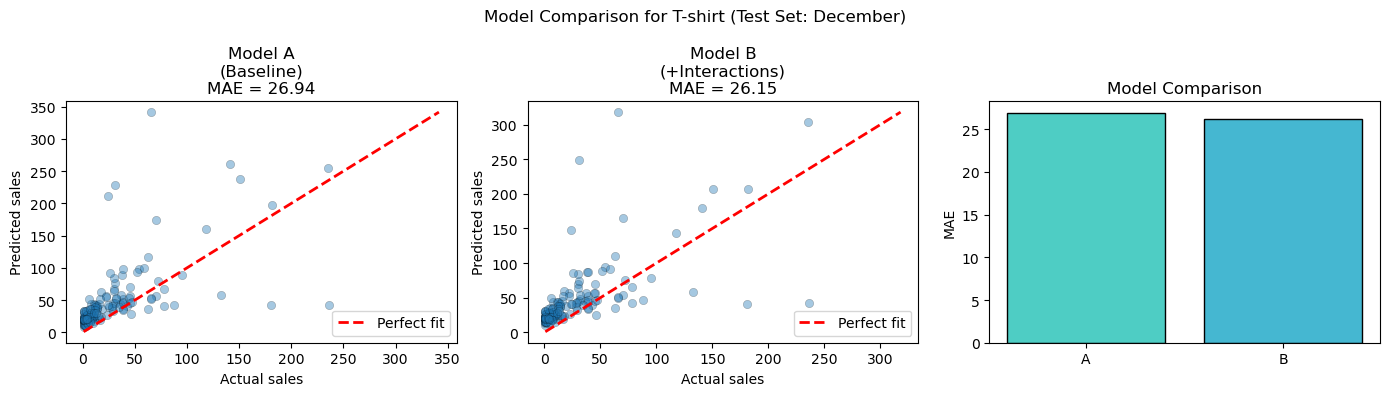

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models = [("Model A\n(Baseline)", pred_C), ("Model B\n(+Interactions)", pred_D)]

for ax, (name, pred) in zip(axes[:2], models):
    mae = mean_absolute_error(y_te, pred)
    ax.scatter(y_te, pred, alpha=0.4, edgecolor="k", linewidth=0.3)
    lims = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
    ax.set_xlabel("Actual sales")
    ax.set_ylabel("Predicted sales")
    ax.set_title(f"{name}\nMAE = {mae:.2f}")
    ax.legend()

# Bar plot
maes = [mean_absolute_error(y_te, pred_C), mean_absolute_error(y_te, pred_D)]
axes[2].bar(["A", "B"], maes, color=["#4ecdc4", "#45b7d1"], edgecolor="k")
axes[2].set_ylabel("MAE")
axes[2].set_title("Model Comparison")

fig.suptitle(f"Model Comparison for {SELECTED_PRODUCT} (Test Set: December)", fontsize=12)
plt.tight_layout()
plt.show()

## Feature Importance

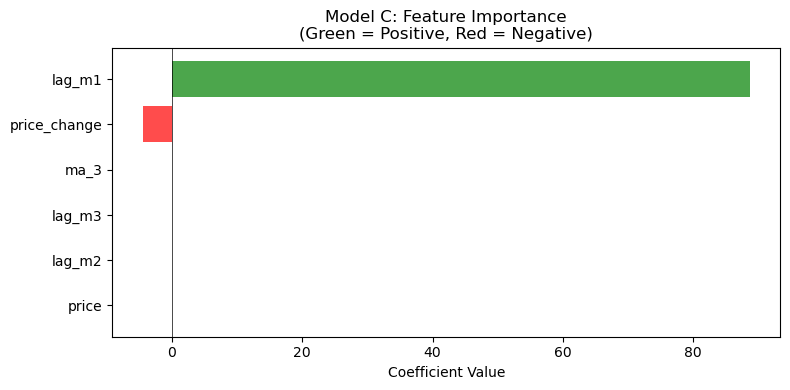

In [16]:
# Model C feature importance
coefs_C = pd.DataFrame({
    'Feature': modelC_num,
    'Coefficient': lasso_C.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in coefs_C['Coefficient']]
ax.barh(coefs_C['Feature'], coefs_C['Coefficient'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient Value')
ax.set_title('Model C: Feature Importance\n(Green = Positive, Red = Negative)')
plt.tight_layout()
plt.show()

In [17]:
# Model D feature importance
coefs_D = pd.DataFrame({
    'Feature': feature_names_D,
    'Coefficient': lasso_D.coef_
})

# Filter to non-zero coefficients and sort
coefs_D_nonzero = coefs_D[coefs_D['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(coefs_D_nonzero) * 0.3)))
colors = ['green' if c > 0 else 'red' for c in coefs_D_nonzero['Coefficient']]
ax.barh(coefs_D_nonzero['Feature'], coefs_D_nonzero['Coefficient'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient Value')
ax.set_title('Model D: Feature Importance (Non-zero coefficients)\n(Green = Positive, Red = Negative)')
plt.tight_layout()
plt.show()

NameError: name 'feature_names_D' is not defined

---
## Questions

### Question 1: Model Complexity and Performance

Model B has many more features than Model A due to the interaction terms.

**Q1a:** Did adding interaction terms improve the forecast accuracy? By how much?

*Your answer:*



**Q1b:** LASSO automatically selected which features to keep (non-zero coefficients). Why is this automatic feature selection especially important when we add many interaction terms?

*Your answer:*



---
### Question 2: Interpreting Feature Importance

Look at the feature importance plots above.

**Q2a:** Which feature has the strongest effect on predicted sales in Model A? Does the sign (positive/negative) make business sense?

*Your answer:*



**Q2b:** Look at the top interaction terms in Model B. Pick one interaction and explain what it might mean in business terms. For example, what would a positive coefficient on `price lag_m1` mean?

*Your answer:*



---
### Question 3: Comparing Products

In [ ]:
# ============================================================
# EXERCISE: Analyze a different product
# ============================================================
PRODUCT_2 = "Dress"  # <-- Choose a different product (e.g., "Dress", "Sweater", "Jacket")

def analyze_product(product_name):
    df_p = df[df["name"] == product_name].copy()
    ids_Cll = df_p.groupby("id")[month_cols].sum().sum(axis=1)
    valid = ids_Cll[ids_Cll == 12].index
    df_p = df_p[df_p["id"].isin(valid)].copy()
    
    df_p["month_num"] = df_p[month_cols].idxmax(axis=1).map({m: i+1 for i, m in enumerate(month_cols)})
    for i in range(1, 4):
        df_p[f"lag_m{i}"] = df_p.groupby("id")["sales"].shift(i)
    df_p["ma_3"] = df_p.groupby("id")["sales"].shift(1).rolling(3, min_periods=1).mean().values
    df_p["price_change"] = df_p.groupby("id")["price"].pct_change()
    df_p = df_p.fillna(0)
    
    months = np.sort(df_p["month_num"].unique())
    tr = df_p[df_p["month_num"] < months[-1]]
    te = df_p[df_p["month_num"] == months[-1]]
    
    feats = ["price", "price_change", "lag_m1", "lag_m2", "lag_m3", "ma_3"]
    sc = StandardScaler()
    X_tr = sc.fit_transform(tr[feats])
    X_te = sc.transform(te[feats])
    
    model = LassoCV(cv=100, random_state=0).fit(X_tr, tr["sales"])
    preds = model.predict(X_te)
    return mean_absolute_error(te["sales"], preds), te["sales"].mean()

mae_2, avg_2 = analyze_product(PRODUCT_2)
mae_1, avg_1 = mean_absolute_error(y_te, pred_C), y_te.mean()

print(f"{SELECTED_PRODUCT}: MAE = {mae_1:.2f}")
print(f"{PRODUCT_2}: MAE = {mae_2:.2f}")

**Q3:** Compare the two products. Which is easier to forecast (lower mean absolute error)? Why might some product categories be more predictable than others?

*Your answer:*



---
### Question 4: Business Application — Inventory Planning

You are an inventory manager at H&M preparing stock levels for next December.

In [ ]:
# Analyze prediction errors
errors = pred_C - y_te

print(f"Prediction Error Summary:")
print(f"  Average error: {errors.mean():.1f} units")
print(f"  Std deviation: {errors.std():.1f} units")
print(f"\n  Under-predictions (stockouts): {(errors < 0).sum()} products")
print(f"  Over-predictions (excess):     {(errors > 0).sum()} products")
print(f"\n  Worst under-prediction: {errors.min():.0f} units")
print(f"  Worst over-prediction:  {errors.max():.0f} units")

**Q4a:** For fashion retail, what are some risks of under-predicting demand (leading to stockouts) or over-predicting demand (leading to excess inventory)? Which is worse?

*Your answer:*



**Q4b:** Given your answer above, would you recommend H&M order exactly what the model predicts, or adjust it slightly? How would you decide how to adjust the predictions?

*Your answer:*



---
### Question 5: Model Limitations

**Q5:** Our model relies heavily on lag features (past sales) to predict future sales. Describe two real-world scenarios where this approach would fail, and suggest what data H&M could use instead.

*Your answer:*

